<a href="https://colab.research.google.com/github/pfjonatan-cloud/Big-Data-Lesiones/blob/main/jonatan_santos_M10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primero importo librerias

In [5]:
# primero importo las librerias:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


Voy a usar el archivo del modulo 9, datos de GPS de una semana

In [9]:
df = pd.read_excel("/GPS.xlsx")

df.head()

,Jornada,Semana,Microciclo,Dia,Players,Positions,Match_Days,Distance,Duration,HSR,Player_Load,Acc_AI,Dec _AI,Max Acceleration (m/s²),Max Deceleration (m/s²),Vel_Zona_4,Vel_Zona_5,Vel_Zona_6,Max_Speed
0,4,20,22,2022-11-15,Jugador 15,Central,-5 MD,5628.52,64.33,116.34,102.13,33,47,5.53,-6.70,148.22,68.70,10.50,25.66
1,4,20,22,2022-11-15,Jugador 22,Central,-5 MD,4853.08,64.33,56.87,68.67,38,48,4.95,-5.49,113.24,25.73,9.53,24.90
2,4,20,22,2022-11-15,Jugador 14,Central,-5 MD,4750.03,64.33,59.38,66.78,39,41,4.47,-5.65,99.72,30.19,4.20,25.00
3,4,20,22,2022-11-15,Jugador 20,Delantero,-5 MD,4884.74,64.33,127.42,72.63,43,48,5.24,-5.05,195.67,60.32,35.94,26.83
4,4,20,22,2022-11-15,Jugador 13,Delantero,-5 MD,5170.83,64.33,81.37,70.71,30,37,4.70,-5.84,160.06,48.17,15.94,26.63


## Exploración inicial

Antes de analizar, necesitamos entender:

- tamaño del dataset
- tipos de variables
- posibles problemas

In [11]:
print("Número de filas del dataset:", df.shape[0])
print("Número de columnas del dataset:", df.shape[1])

Número de filas del dataset: 102
Número de columnas del dataset: 19


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Jornada                  102 non-null    int64         
 1   Semana                   102 non-null    int64         
 2   Microciclo               102 non-null    int64         
 3   Dia                      102 non-null    datetime64[ns]
 4   Players                  102 non-null    object        
 5   Positions                102 non-null    object        
 6   Match_Days               102 non-null    object        
 7   Distance                 102 non-null    float64       
 8   Duration                 102 non-null    float64       
 9   HSR                      102 non-null    float64       
 10  Player_Load              102 non-null    float64       
 11  Acc_AI                   102 non-null    int64         
 12  Dec _AI                  102 non-nul

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.describe()

,Jornada,Semana,Microciclo,Dia,Distance,Duration,HSR,Player_Load,Acc_AI,Dec _AI,Max Acceleration (m/s²),Max Deceleration (m/s²),Vel_Zona_4,Vel_Zona_5,Vel_Zona_6,Max_Speed
count,102.0,102.0,102.0,102,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,4.0,20.0,22.0,2022-11-16 23:31:45.882352896,4419.963627,62.424216,128.198824,67.098137,31.627451,35.450980,4.794608,-5.649902,132.468824,61.835784,36.309510,27.314314
min,4.0,20.0,22.0,2022-11-15 00:00:00,2719.480000,42.210000,0.000000,37.580000,10.000000,19.000000,3.900000,-9.370000,1.610000,0.000000,0.000000,18.170000
25%,4.0,20.0,22.0,2022-11-16 00:00:00,3259.370000,59.310000,59.417500,49.010000,23.250000,27.000000,4.375000,-6.020000,89.337500,26.812500,6.995000,25.010000
50%,4.0,20.0,22.0,2022-11-17 00:00:00,4818.475000,61.510000,110.270000,70.325000,31.000000,34.500000,4.715000,-5.625000,116.060000,57.980000,26.410000,27.155000
75%,4.0,20.0,22.0,2022-11-18 00:00:00,5256.877500,64.330000,172.267500,81.410000,39.750000,42.750000,5.095000,-5.055000,162.302500,83.582500,53.632500,29.685000
max,4.0,20.0,22.0,2022-11-19 00:00:00,6661.300000,85.450000,506.690000,102.130000,58.000000,65.000000,7.690000,-4.290000,368.090000,292.360000,174.760000,34.050000
std,0.0,0.0,0.0,NaN,1099.903533,13.668739,94.128970,18.740646,10.832589,10.207382,0.575618,0.786844,66.537048,44.468938,37.854865,3.313530


In [16]:
# Creo una copia actualizada del dataset original

df_sesion = df.copy()

# Verifico que las columnas estén correctamente cargadas
df_sesion.columns.tolist()

['Jornada',
 'Semana',
 'Microciclo',
 'Dia',
 'Players',
 'Positions',
 'Match_Days',
 'Distance',
 'Duration',
 'HSR',
 'Player_Load ',
 'Acc_AI',
 'Dec _AI',
 'Max Acceleration (m/s²)',
 'Max Deceleration (m/s²)',
 'Vel_Zona_4',
 'Vel_Zona_5',
 'Vel_Zona_6',
 'Max_Speed ']

In [17]:
# Limpio espacios al inicio y al final de los nombres de columnas

df_sesion.columns = df_sesion.columns.str.strip()

# Verifico nuevamente los nombres de columnas
df_sesion.columns.tolist()

['Jornada',
 'Semana',
 'Microciclo',
 'Dia',
 'Players',
 'Positions',
 'Match_Days',
 'Distance',
 'Duration',
 'HSR',
 'Player_Load',
 'Acc_AI',
 'Dec _AI',
 'Max Acceleration (m/s²)',
 'Max Deceleration (m/s²)',
 'Vel_Zona_4',
 'Vel_Zona_5',
 'Vel_Zona_6',
 'Max_Speed']

In [19]:
# Agrego columnas sintéticas de Wellness y RPE relacionadas con Distance

import numpy as np

np.random.seed(42)

# Normalizo Distance dentro de cada día
df_sesion["Distance_norm_dia"] = df_sesion.groupby("Dia")["Distance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5
)

# Wellness: escala 1 a 5
df_sesion["Wellness"] = 2 + (df_sesion["Distance_norm_dia"] * 2)
df_sesion["Wellness"] = df_sesion["Wellness"] + np.random.normal(0, 0.35, len(df_sesion))
df_sesion["Wellness"] = df_sesion["Wellness"].round().clip(2, 4)

# Casos excepcionales de Wellness
prob_wellness = np.random.rand(len(df_sesion))
df_sesion.loc[prob_wellness < 0.03, "Wellness"] = 1
df_sesion.loc[prob_wellness > 0.97, "Wellness"] = 5

df_sesion["Wellness"] = df_sesion["Wellness"].astype(int)

# RPE: escala 1 a 10
df_sesion["RPE"] = 3 + (df_sesion["Distance_norm_dia"] * 5)
df_sesion["RPE"] = df_sesion["RPE"] + np.random.normal(0, 0.8, len(df_sesion))
df_sesion["RPE"] = df_sesion["RPE"].round().clip(2, 9)

# Casos excepcionales de RPE
prob_rpe = np.random.rand(len(df_sesion))
df_sesion.loc[prob_rpe < 0.02, "RPE"] = 1
df_sesion.loc[prob_rpe > 0.98, "RPE"] = 10

df_sesion["RPE"] = df_sesion["RPE"].astype(int)

# Elimino columna auxiliar
df_sesion = df_sesion.drop(columns=["Distance_norm_dia"])

# Reviso las primeras filas
df_sesion.head()

,Jornada,Semana,Microciclo,Dia,Players,Positions,Match_Days,Distance,Duration,HSR,...,Acc_AI,Dec _AI,Max Acceleration (m/s²),Max Deceleration (m/s²),Vel_Zona_4,Vel_Zona_5,Vel_Zona_6,Max_Speed,Wellness,RPE
0,4,20,22,2022-11-15,Jugador 15,Central,-5 MD,5628.52,64.33,116.34,...,33,47,5.53,-6.70,148.22,68.70,10.50,25.66,4,8
1,4,20,22,2022-11-15,Jugador 22,Central,-5 MD,4853.08,64.33,56.87,...,38,48,4.95,-5.49,113.24,25.73,9.53,24.90,3,5
2,4,20,22,2022-11-15,Jugador 14,Central,-5 MD,4750.03,64.33,59.38,...,39,41,4.47,-5.65,99.72,30.19,4.20,25.00,3,5
3,4,20,22,2022-11-15,Jugador 20,Delantero,-5 MD,4884.74,64.33,127.42,...,43,48,5.24,-5.05,195.67,60.32,35.94,26.83,4,6
4,4,20,22,2022-11-15,Jugador 13,Delantero,-5 MD,5170.83,64.33,81.37,...,30,37,4.70,-5.84,160.06,48.17,15.94,26.63,3,6


Ya tenemos los valores sin nulos, ahora empezamos a analizar los valores con el obejtivo de determinar que jugadores llegan mejor preparados para el proximo partido:

- Carga media de cada dia
- Identificar jugadors outliders (necesidad de ajustar al dia siguiente)
- Nivel de carga cumulada como variable relacionada con wellness

In [20]:
# Carga media por día

carga_diaria = df_sesion.groupby("Dia").agg({
    "Distance": "mean",
    "Player_Load": "mean",
    "HSR": "mean",
    "RPE": "mean",
    "Wellness": "mean"
}).reset_index()

carga_diaria

,Dia,Distance,Player_Load,HSR,RPE,Wellness
0,2022-11-15,5101.323333,77.114286,122.815714,5.714286,3.333333
1,2022-11-16,5152.412000,78.044000,150.081000,6.350000,2.900000
2,2022-11-17,5371.913810,84.424286,191.146667,5.428571,3.047619
3,2022-11-18,3106.001500,45.040000,133.698500,5.150000,2.450000
4,2022-11-19,3286.502000,49.501000,40.374000,5.000000,3.000000


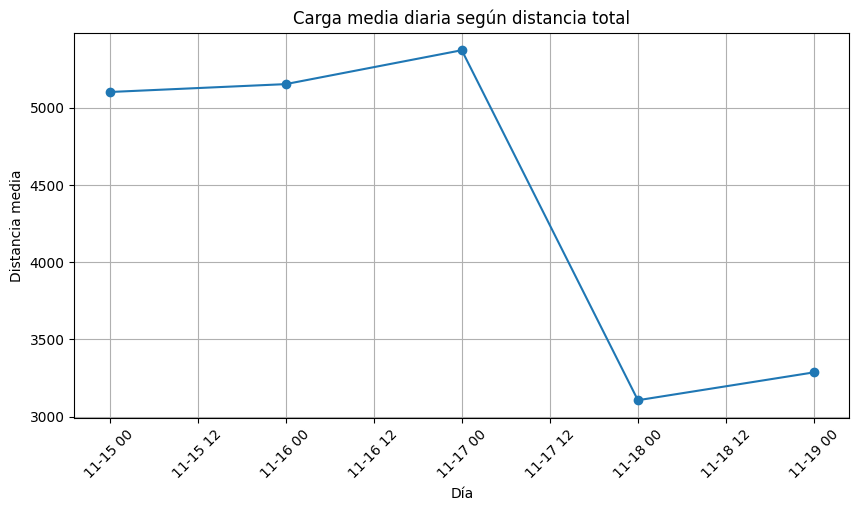

In [21]:
# Visualizo la carga media diaria según Distance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(carga_diaria["Dia"], carga_diaria["Distance"], marker="o")

plt.title("Carga media diaria según distancia total")
plt.xlabel("Día")
plt.ylabel("Distancia media")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Este grafico nos permite visualizar el comportamiento de la carga media del equipo. Se observa que al final de la semana -2 y -1 la decision de planificacion fue reducir considerablemente la carga pensando en el partido del dia 20-11

In [22]:
# KPIs globales del microciclo

kpis_globales = df_sesion[
    [
        "Distance",
        "Player_Load",
        "HSR",
        "RPE",
        "Wellness"
    ]
].mean().round(2)

kpis_globales

,0
Distance,4419.96
Player_Load,67.10
HSR,128.20
RPE,5.53
Wellness,2.95


Los KPIs globales permiten obtener una primera lectura del comportamiento general del microciclo. Estos valores resumen la carga externa media, la percepción subjetiva del esfuerzo y el estado de wellness del grupo. Funcionan como punto de partida para luego analizar diferencias por día, por jugador y por posición.

In [23]:
# Normalizo Wellness y RPE para compararlos en una escala común de 0 a 1

df_sesion["Wellness_norm"] = (df_sesion["Wellness"] - 1) / (5 - 1)

df_sesion["RPE_norm"] = (df_sesion["RPE"] - 1) / (10 - 1)

# Invierto RPE para que mayor valor signifique mejor estado
# RPE bajo = mejor recuperación relativa
# RPE alto = mayor carga interna percibida

df_sesion["RPE_invertido_norm"] = 1 - df_sesion["RPE_norm"]

# Reviso las primeras filas
df_sesion[[
    "Dia",
    "Players",
    "Distance",
    "Wellness",
    "Wellness_norm",
    "RPE",
    "RPE_norm",
    "RPE_invertido_norm"
]].head()

,Dia,Players,Distance,Wellness,Wellness_norm,RPE,RPE_norm,RPE_invertido_norm
0,2022-11-15,Jugador 15,5628.52,4,0.75,8,0.777778,0.222222
1,2022-11-15,Jugador 22,4853.08,3,0.50,5,0.444444,0.555556
2,2022-11-15,Jugador 14,4750.03,3,0.50,5,0.444444,0.555556
3,2022-11-15,Jugador 20,4884.74,4,0.75,6,0.555556,0.444444
4,2022-11-15,Jugador 13,5170.83,3,0.50,6,0.555556,0.444444


In [24]:
# Promedio por jugador de las variables normalizadas

jugadores_normalizados = df_sesion.groupby("Players").agg({
    "Wellness": "mean",
    "RPE": "mean",
    "Wellness_norm": "mean",
    "RPE_norm": "mean",
    "RPE_invertido_norm": "mean",
    "Distance": "sum",
    "Player_Load": "sum",
    "HSR": "sum"
}).reset_index()

jugadores_normalizados = jugadores_normalizados.round(2)

jugadores_normalizados

,Players,Wellness,RPE,Wellness_norm,RPE_norm,RPE_invertido_norm,Distance,Player_Load,HSR
0,Jugador 1,3.00,3.00,0.50,0.22,0.78,2994.69,38.11,0.00
1,Jugador 10,3.20,6.00,0.55,0.56,0.44,22290.45,304.61,984.38
2,Jugador 11,2.60,4.00,0.40,0.33,0.67,18912.23,280.18,314.47
3,Jugador 12,2.40,3.40,0.35,0.27,0.73,20207.48,316.48,639.06
4,Jugador 13,3.40,6.80,0.60,0.64,0.36,23613.15,330.60,806.27
5,Jugador 14,2.40,4.80,0.35,0.42,0.58,20639.15,297.12,384.31
6,Jugador 15,3.20,5.60,0.55,0.51,0.49,22128.23,383.85,496.51
7,Jugador 16,3.00,6.20,0.50,0.58,0.42,22718.53,352.51,746.38
8,Jugador 17,3.80,7.60,0.70,0.73,0.27,24681.03,386.58,1123.44
9,Jugador 18,3.20,5.00,0.55,0.44,0.56,21145.62,335.99,1124.03


In [25]:
# Índice simple de preparación subjetiva

jugadores_normalizados["Indice_subjetivo_preparacion"] = (
    jugadores_normalizados["Wellness_norm"] * 0.5 +
    jugadores_normalizados["RPE_invertido_norm"] * 0.5
).round(2)

# Ordeno de mayor a menor preparación subjetiva
jugadores_normalizados = jugadores_normalizados.sort_values(
    "Indice_subjetivo_preparacion",
    ascending=False
)

jugadores_normalizados[[
    "Players",
    "Wellness",
    "RPE",
    "Wellness_norm",
    "RPE_invertido_norm",
    "Indice_subjetivo_preparacion"
]]

,Players,Wellness,RPE,Wellness_norm,RPE_invertido_norm,Indice_subjetivo_preparacion
0,Jugador 1,3.00,3.00,0.50,0.78,0.64
9,Jugador 18,3.20,5.00,0.55,0.56,0.56
13,Jugador 22,3.00,4.60,0.50,0.60,0.55
18,Jugador 5,2.80,4.40,0.45,0.62,0.54
12,Jugador 20,3.00,4.80,0.50,0.58,0.54
2,Jugador 11,2.60,4.00,0.40,0.67,0.54
3,Jugador 12,2.40,3.40,0.35,0.73,0.54
15,Jugador 24,3.00,5.00,0.50,0.56,0.53
6,Jugador 15,3.20,5.60,0.55,0.49,0.52
10,Jugador 19,3.20,5.80,0.55,0.47,0.51


Para comparar Wellness y RPE se aplicó una normalización Min-Max, llevando ambas variables a una escala común de 0 a 1. Además, el RPE fue invertido porque su interpretación es opuesta al wellness: un valor alto de wellness representa mejor estado, mientras que un valor alto de RPE representa mayor esfuerzo percibido. De esta manera, ambas variables pueden leerse en la misma dirección: valores más altos indican mejor preparación subjetiva.


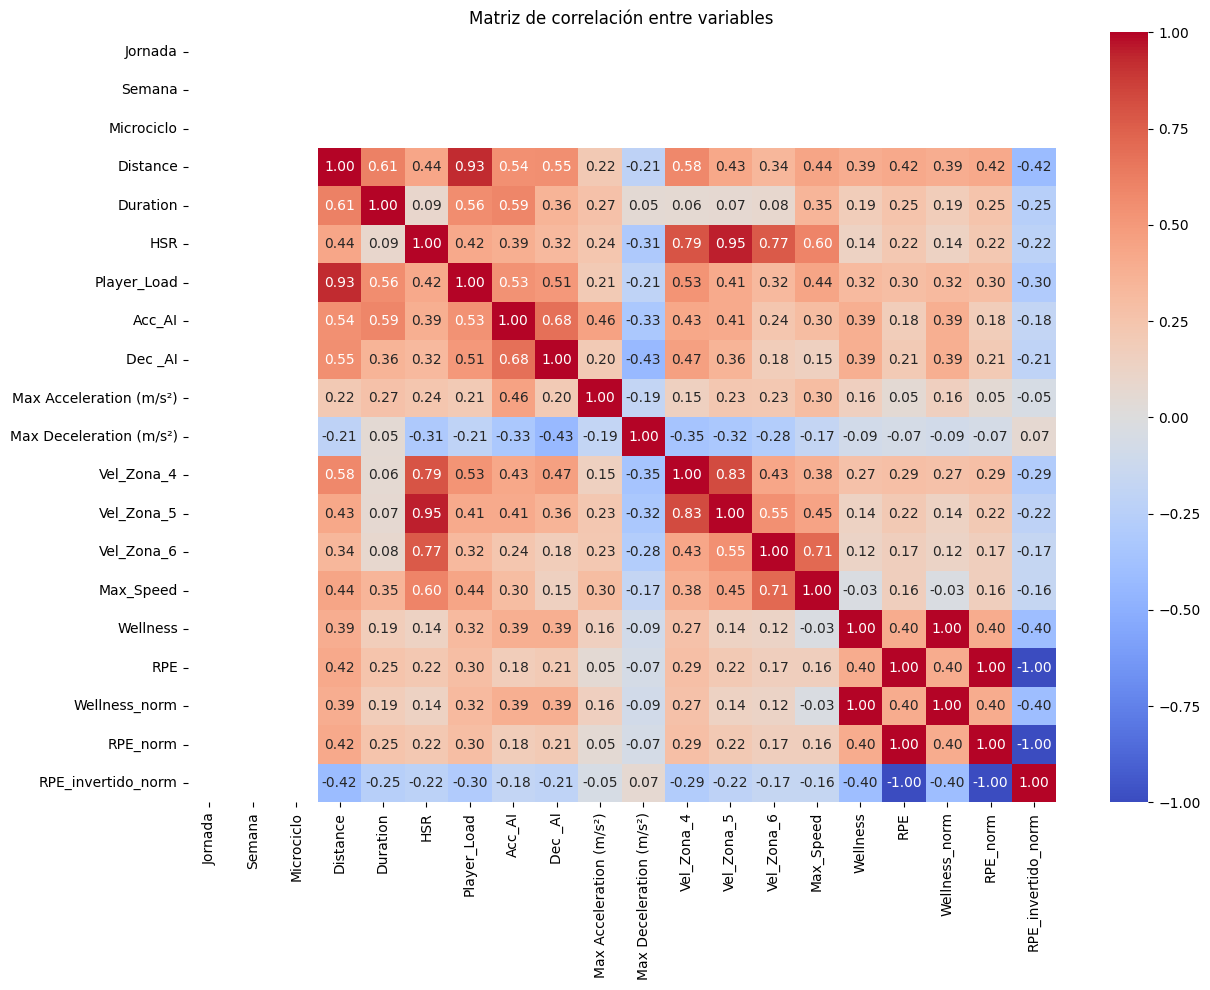

In [26]:
# Matriz de correlación entre variables numéricas

corr = df_sesion.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables")
plt.show()

In [27]:
# Creo variables relativas por minuto

df_sesion["Distance_min"] = df_sesion["Distance"] / df_sesion["Duration"]
df_sesion["Player_Load_min"] = df_sesion["Player_Load"] / df_sesion["Duration"]
df_sesion["HSR_min"] = df_sesion["HSR"] / df_sesion["Duration"]
df_sesion["Vel_Zona_4_min"] = df_sesion["Vel_Zona_4"] / df_sesion["Duration"]
df_sesion["Vel_Zona_5_min"] = df_sesion["Vel_Zona_5"] / df_sesion["Duration"]
df_sesion["Vel_Zona_6_min"] = df_sesion["Vel_Zona_6"] / df_sesion["Duration"]

# Reviso las primeras filas con las nuevas variables
df_sesion[[
    "Players",
    "Positions",
    "Dia",
    "Duration",
    "Distance_min",
    "Player_Load_min",
    "HSR_min",
    "Vel_Zona_4_min",
    "Vel_Zona_5_min",
    "Vel_Zona_6_min"
]].head()

,Players,Positions,Dia,Duration,Distance_min,Player_Load_min,HSR_min,Vel_Zona_4_min,Vel_Zona_5_min,Vel_Zona_6_min
0,Jugador 15,Central,2022-11-15,64.33,87.494482,1.587595,1.808487,2.304057,1.067931,0.163221
1,Jugador 22,Central,2022-11-15,64.33,75.440386,1.067465,0.884035,1.760298,0.399969,0.148142
2,Jugador 14,Central,2022-11-15,64.33,73.838489,1.038085,0.923053,1.550132,0.469299,0.065288
3,Jugador 20,Delantero,2022-11-15,64.33,75.932535,1.129022,1.980724,3.041660,0.937665,0.558682
4,Jugador 13,Delantero,2022-11-15,64.33,80.379761,1.099176,1.264884,2.488108,0.748795,0.247785


Antes de comparar jugadores, se calcularon variables relativas por minuto. Esto permite reducir el sesgo generado por diferencias en la duración de la sesión y comparar la intensidad relativa de cada jugador con mayor precisión.

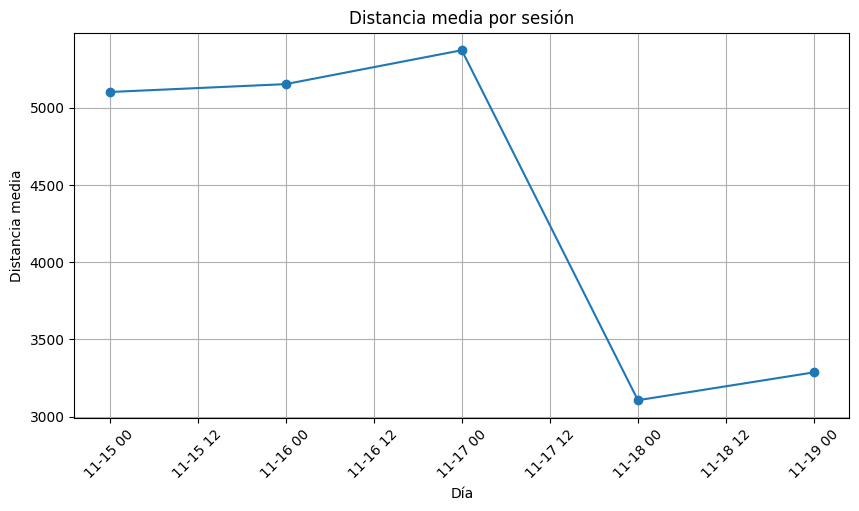

In [28]:
# Gráfico 1: distancia media por día

carga_diaria = df_sesion.groupby("Dia").agg({
    "Distance": "mean",
    "Player_Load": "mean",
    "HSR": "mean",
    "RPE": "mean",
    "Wellness": "mean"
}).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(carga_diaria["Dia"], carga_diaria["Distance"], marker="o")

plt.title("Distancia media por sesión")
plt.xlabel("Día")
plt.ylabel("Distancia media")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

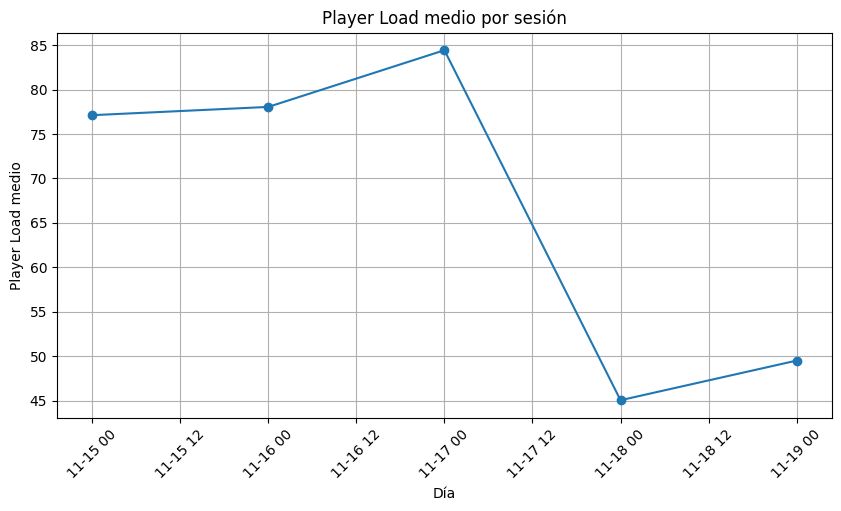

In [29]:
# Gráfico 2: Player Load medio por día

plt.figure(figsize=(10, 5))
plt.plot(carga_diaria["Dia"], carga_diaria["Player_Load"], marker="o")

plt.title("Player Load medio por sesión")
plt.xlabel("Día")
plt.ylabel("Player Load medio")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

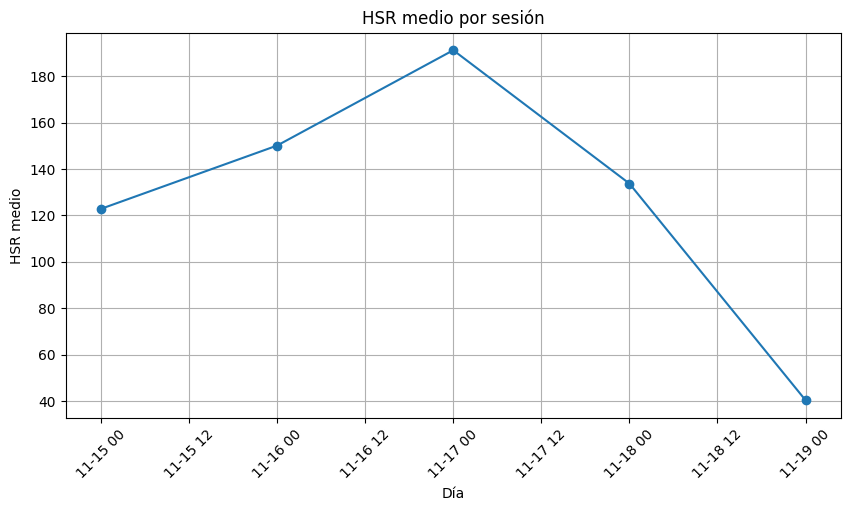

In [30]:
# Gráfico 3: HSR medio por día

plt.figure(figsize=(10, 5))
plt.plot(carga_diaria["Dia"], carga_diaria["HSR"], marker="o")

plt.title("HSR medio por sesión")
plt.xlabel("Día")
plt.ylabel("HSR medio")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

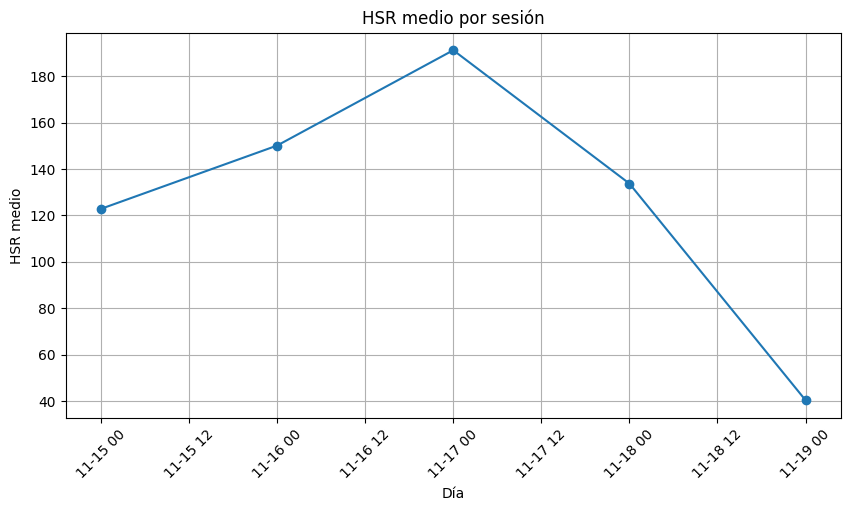

In [31]:
# Gráfico 3: HSR medio por día

plt.figure(figsize=(10, 5))
plt.plot(carga_diaria["Dia"], carga_diaria["HSR"], marker="o")

plt.title("HSR medio por sesión")
plt.xlabel("Día")
plt.ylabel("HSR medio")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

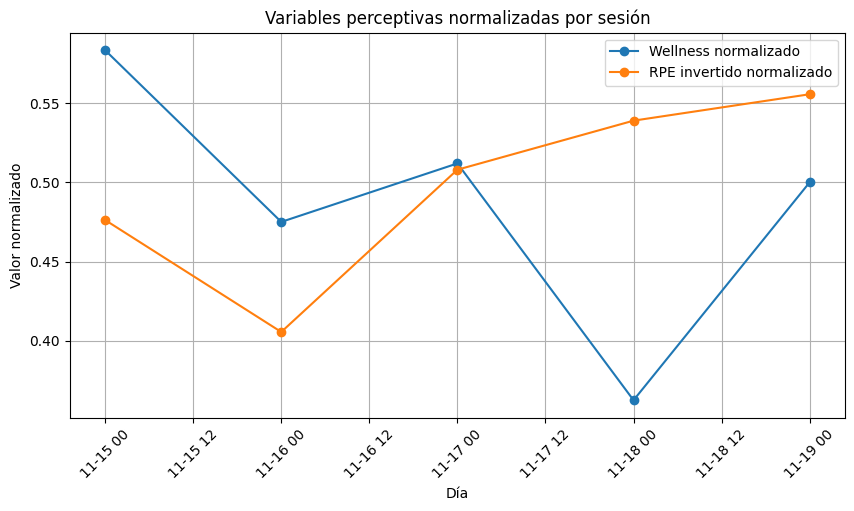

In [32]:
# Gráfico 4: Wellness y RPE invertido normalizados por día

percepcion_diaria = df_sesion.groupby("Dia").agg({
    "Wellness_norm": "mean",
    "RPE_invertido_norm": "mean"
}).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(percepcion_diaria["Dia"], percepcion_diaria["Wellness_norm"], marker="o", label="Wellness normalizado")
plt.plot(percepcion_diaria["Dia"], percepcion_diaria["RPE_invertido_norm"], marker="o", label="RPE invertido normalizado")

plt.title("Variables perceptivas normalizadas por sesión")
plt.xlabel("Día")
plt.ylabel("Valor normalizado")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

Se observa una tendencia positiva hacia el final de la semana: con la reducción de la carga, el RPE invertido aumenta y el wellness mejora del día -2 al día -1. Esto sugiere una posible respuesta favorable de recuperación antes del partido. Aun así, la relación no es perfecta y debe analizarse jugador por jugador.

In [33]:
# Resumen individual semanal por jugador

resumen_jugadores = df_sesion.groupby(["Players", "Positions"]).agg({
    "Distance": "sum",
    "Player_Load": "sum",
    "HSR": "sum",
    "Vel_Zona_4": "sum",
    "Vel_Zona_5": "sum",
    "Vel_Zona_6": "sum",
    "Max_Speed": "max",
    "RPE": "mean",
    "Wellness": "mean",
    "Distance_min": "mean",
    "Player_Load_min": "mean",
    "HSR_min": "mean"
}).reset_index()

# Redondeo para visualizar mejor
resumen_jugadores = resumen_jugadores.round(2)

# Ordeno por mayor carga acumulada
resumen_jugadores = resumen_jugadores.sort_values("Distance", ascending=False)

resumen_jugadores

,Players,Positions,Distance,Player_Load,HSR,Vel_Zona_4,Vel_Zona_5,Vel_Zona_6,Max_Speed,RPE,Wellness,Distance_min,Player_Load_min,HSR_min
16,Jugador 3,Mediocentro,25919.19,389.11,787.31,931.04,390.35,164.22,32.29,7.00,3.20,83.28,1.25,2.70
8,Jugador 17,Lateral,24681.03,386.58,1123.44,999.56,519.78,350.81,31.13,7.60,3.80,80.02,1.25,3.99
10,Jugador 19,Lateral,23862.96,358.55,983.98,831.41,434.01,391.62,32.84,5.80,3.20,76.73,1.15,3.32
11,Jugador 2,Mediocentro,23650.07,320.00,304.07,501.27,158.81,64.47,31.76,7.40,3.00,76.10,1.02,0.96
4,Jugador 13,Delantero,23613.15,330.60,806.27,869.22,364.21,245.15,32.19,6.80,3.40,75.79,1.06,2.62
17,Jugador 4,Mediocentro,22996.18,339.01,266.13,578.37,148.69,54.44,29.88,5.60,2.80,74.30,1.09,0.85
7,Jugador 16,Mediocentro,22718.53,352.51,746.38,719.41,385.26,189.62,31.39,6.20,3.00,72.50,1.12,2.40
21,Jugador 8,Extremo,22649.75,322.73,704.40,818.17,357.29,169.44,32.39,6.40,3.20,72.90,1.04,2.23
1,Jugador 10,Extremo,22290.45,304.61,984.38,906.83,491.89,248.42,32.27,6.00,3.20,71.48,0.97,3.38
6,Jugador 15,Central,22128.23,383.85,496.51,548.40,219.71,153.22,30.25,5.60,3.20,71.18,1.23,1.62


In [34]:
# Creo función para normalizar variables entre 0 y 1

def normalizar_01(serie):
    if serie.max() == serie.min():
        return serie * 0
    return (serie - serie.min()) / (serie.max() - serie.min())


# Normalizo variables asociadas a mayor criticidad

resumen_jugadores["Distance_norm"] = normalizar_01(resumen_jugadores["Distance"])
resumen_jugadores["Player_Load_norm"] = normalizar_01(resumen_jugadores["Player_Load"])
resumen_jugadores["HSR_norm"] = normalizar_01(resumen_jugadores["HSR"])
resumen_jugadores["RPE_norm"] = (resumen_jugadores["RPE"] - 1) / (10 - 1)

# Wellness se invierte porque menor wellness implica mayor criticidad
resumen_jugadores["Wellness_invertido_norm"] = 1 - ((resumen_jugadores["Wellness"] - 1) / (5 - 1))

# Índice de criticidad
resumen_jugadores["Indice_criticidad"] = (
    resumen_jugadores["Distance_norm"] * 0.30 +
    resumen_jugadores["Player_Load_norm"] * 0.25 +
    resumen_jugadores["HSR_norm"] * 0.20 +
    resumen_jugadores["RPE_norm"] * 0.15 +
    resumen_jugadores["Wellness_invertido_norm"] * 0.10
)

# Ordeno de mayor a menor criticidad
jugadores_criticos = resumen_jugadores.sort_values(
    "Indice_criticidad",
    ascending=False
)

jugadores_criticos[[
    "Players",
    "Positions",
    "Distance",
    "Player_Load",
    "HSR",
    "RPE",
    "Wellness",
    "Indice_criticidad"
]].round(2)

,Players,Positions,Distance,Player_Load,HSR,RPE,Wellness,Indice_criticidad
8,Jugador 17,Lateral,24681.03,386.58,1123.44,7.60,3.80,0.86
16,Jugador 3,Mediocentro,25919.19,389.11,787.31,7.00,3.20,0.82
10,Jugador 19,Lateral,23862.96,358.55,983.98,5.80,3.20,0.79
9,Jugador 18,Lateral,21145.62,335.99,1124.03,5.00,3.20,0.75
4,Jugador 13,Delantero,23613.15,330.60,806.27,6.80,3.40,0.75
7,Jugador 16,Mediocentro,22718.53,352.51,746.38,6.20,3.00,0.74
1,Jugador 10,Extremo,22290.45,304.61,984.38,6.00,3.20,0.74
19,Jugador 6,Lateral,21335.54,372.78,620.07,5.20,2.40,0.71
21,Jugador 8,Extremo,22649.75,322.73,704.40,6.40,3.20,0.71
12,Jugador 20,Delantero,21265.72,319.88,930.17,4.80,3.00,0.71


Se construyó un índice de criticidad individual combinando carga acumulada, Player Load, HSR, RPE promedio y wellness invertido. Los jugadores con valores más altos presentan mayor carga semanal relativa y peores señales perceptivas, por lo que deberían ser monitoreados con mayor atención antes del partido.

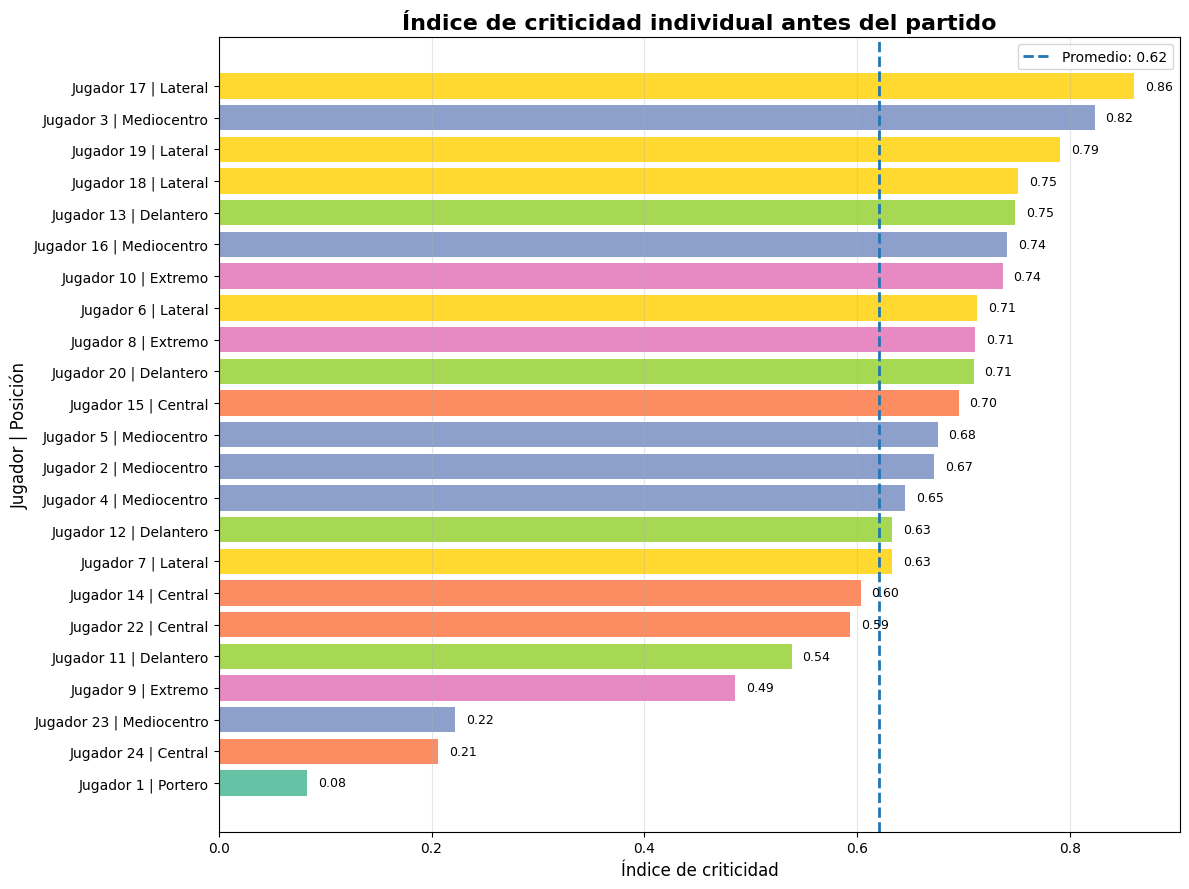

In [36]:
# Gráfico mejorado de criticidad individual por jugador con posición

# Ordeno de menor a mayor para que el más crítico quede arriba
jugadores_criticos_grafico = jugadores_criticos.sort_values(
    "Indice_criticidad",
    ascending=True
).copy()

# Creo etiqueta combinando jugador y posición
jugadores_criticos_grafico["Jugador_Posicion"] = (
    jugadores_criticos_grafico["Players"] + " | " + jugadores_criticos_grafico["Positions"]
)

# Creo paleta de colores por posición
posiciones = jugadores_criticos_grafico["Positions"].unique()
palette = sns.color_palette("Set2", len(posiciones))
color_dict = dict(zip(posiciones, palette))

colores = jugadores_criticos_grafico["Positions"].map(color_dict)

# Promedio del índice
promedio_criticidad = jugadores_criticos_grafico["Indice_criticidad"].mean()

plt.figure(figsize=(12, 9))

bars = plt.barh(
    jugadores_criticos_grafico["Jugador_Posicion"],
    jugadores_criticos_grafico["Indice_criticidad"],
    color=colores
)

# Línea de promedio
plt.axvline(
    promedio_criticidad,
    linestyle="--",
    linewidth=2,
    label=f"Promedio: {promedio_criticidad:.2f}"
)

# Etiquetas de valor al final de cada barra
for bar in bars:
    ancho = bar.get_width()
    plt.text(
        ancho + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{ancho:.2f}",
        va="center",
        fontsize=9
    )

plt.title("Índice de criticidad individual antes del partido", fontsize=16, fontweight="bold")
plt.xlabel("Índice de criticidad", fontsize=12)
plt.ylabel("Jugador | Posición", fontsize=12)

plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

El ranking muestra que varios laterales aparecen entre los jugadores con mayor índice de criticidad. Esto puede estar condicionado por la demanda específica de la posición, ya que los laterales suelen acumular mayor distancia, más metros de alta intensidad y mayor carga externa por su participación en recorridos ofensivos y defensivos.

Por lo tanto, el índice debe interpretarse en dos niveles: primero, como alerta individual de carga acumulada; segundo, como expresión de la demanda posicional. En este caso, no necesariamente todos los laterales están “mal”, pero sí son jugadores que requieren mayor control de recuperación antes del partido.

Es probable que para estos resultados (como preparador fisico del equipo) podria sugerir que si jugamos con 3 - 5 - 2, debemos tener en cuenta que nuestra semana fue exigente para los laterales y tal vez en ese sistema tactico de mas exigencia para los carrileros, puedan llegar condicionados si juegan todo el partido...

In [37]:
# Insights generales del microciclo

pos_max_distancia = df_sesion.groupby("Positions")["Distance"].mean().idxmax()
dia_max_distancia = df_sesion.groupby("Dia")["Distance"].mean().idxmax()
dia_max_player_load = df_sesion.groupby("Dia")["Player_Load"].mean().idxmax()
dia_max_hsr = df_sesion.groupby("Dia")["HSR"].mean().idxmax()

jugador_mayor_criticidad = jugadores_criticos.iloc[0]["Players"]
posicion_mayor_criticidad = jugadores_criticos.iloc[0]["Positions"]
indice_mayor_criticidad = jugadores_criticos.iloc[0]["Indice_criticidad"]

print(f"La posición con mayor distancia media fue: {pos_max_distancia}")
print(f"El día con mayor distancia media fue: {dia_max_distancia}")
print(f"El día con mayor Player Load medio fue: {dia_max_player_load}")
print(f"El día con mayor HSR medio fue: {dia_max_hsr}")
print(f"El jugador con mayor criticidad fue: {jugador_mayor_criticidad} | {posicion_mayor_criticidad} | Índice: {indice_mayor_criticidad:.2f}")

La posición con mayor distancia media fue: Mediocentro
El día con mayor distancia media fue: 2022-11-17 00:00:00
El día con mayor Player Load medio fue: 2022-11-17 00:00:00
El día con mayor HSR medio fue: 2022-11-17 00:00:00
El jugador con mayor criticidad fue: Jugador 17 | Lateral | Índice: 0.86


In [38]:
# Tabla resumen de insights generales

insights_generales = pd.DataFrame({
    "Insight": [
        "Posición con mayor distancia media",
        "Día con mayor distancia media",
        "Día con mayor Player Load medio",
        "Día con mayor HSR medio",
        "Jugador con mayor criticidad"
    ],
    "Resultado": [
        pos_max_distancia,
        dia_max_distancia,
        dia_max_player_load,
        dia_max_hsr,
        f"{jugador_mayor_criticidad} | {posicion_mayor_criticidad}"
    ],
    "Valor": [
        round(df_sesion.groupby("Positions")["Distance"].mean().max(), 2),
        round(df_sesion.groupby("Dia")["Distance"].mean().max(), 2),
        round(df_sesion.groupby("Dia")["Player_Load"].mean().max(), 2),
        round(df_sesion.groupby("Dia")["HSR"].mean().max(), 2),
        round(indice_mayor_criticidad, 2)
    ]
})

insights_generales

,Insight,Resultado,Valor
0,Posición con mayor distancia media,Mediocentro,4705.15
1,Día con mayor distancia media,2022-11-17 00:00:00,5371.91
2,Día con mayor Player Load medio,2022-11-17 00:00:00,84.42
3,Día con mayor HSR medio,2022-11-17 00:00:00,191.15
4,Jugador con mayor criticidad,Jugador 17 | Lateral,0.86


# **La tabla resume los principales hallazgos del microciclo. Permite identificar rápidamente qué posición acumuló mayor distancia media, qué día concentró mayor carga y qué jugador presentó el mayor índice de criticidad antes del partido.**

## **Comprobacion de hipotesis:\**

In [39]:
# Test de Shapiro-Wilk para evaluar normalidad

from scipy.stats import shapiro

variables_normalidad = [
    "Distance",
    "Player_Load",
    "HSR",
    "RPE",
    "Wellness",
    "Indice_criticidad"
]

resultados_normalidad = []

for variable in variables_normalidad:
    stat, p_value = shapiro(jugadores_criticos[variable].dropna())

    if p_value < 0.05:
        decision = "No normal"
    else:
        decision = "Compatible con normalidad"

    resultados_normalidad.append({
        "Variable": variable,
        "Estadístico Shapiro": round(stat, 4),
        "p-value": round(p_value, 4),
        "Decisión": decision
    })

tabla_normalidad = pd.DataFrame(resultados_normalidad)

tabla_normalidad

,Variable,Estadístico Shapiro,p-value,Decisión
0,Distance,0.7025,0.0000,No normal
1,Player_Load,0.7724,0.0001,No normal
2,HSR,0.9638,0.5437,Compatible con normalidad
3,RPE,0.9837,0.9586,Compatible con normalidad
4,Wellness,0.9313,0.1165,Compatible con normalidad
5,Indice_criticidad,0.8113,0.0006,No normal


El test de Shapiro-Wilk mostró que no todas las variables presentan una distribución compatible con normalidad. Las variables Distance, Player_Load e Indice_criticidad tuvieron un p-value menor a 0.05, por lo que se rechaza la hipótesis nula de normalidad.

En cambio, HSR, RPE y Wellness presentaron p-value mayor a 0.05, por lo que no se rechaza la hipótesis nula y pueden considerarse compatibles con una distribución normal.

Estos resultados condicionan la elección de pruebas estadísticas posteriores. P

Para variables no normales conviene utilizar pruebas no paramétricas o análisis descriptivos robustos, mientras que para variables compatibles con normalidad podrían utilizarse pruebas paramétricas si se cumplen también otros supuestos.

### **Hipotesis sugeria: El dt va a cambhiar el sistema de juego para el proximo partido y por lo tanto vamos a entrenar mas aspectos de funcionamiento que involucran a los carrilleron con mas funciones y mas recorrido.**

In [40]:
# Creo grupo posicional: laterales vs resto de jugadores

resumen_jugadores["Grupo_posicional"] = resumen_jugadores["Positions"].apply(
    lambda x: "Laterales" if x == "Lateral" else "Resto"
)

# Reviso cantidad de jugadores por grupo
resumen_jugadores["Grupo_posicional"].value_counts()

,count
Grupo_posicional,
Resto,18
Laterales,5


In [41]:
# Comparación descriptiva entre laterales y resto

comparacion_posicional = resumen_jugadores.groupby("Grupo_posicional").agg({
    "Distance": ["mean", "std", "min", "max"],
    "Player_Load": ["mean", "std", "min", "max"],
    "HSR": ["mean", "std", "min", "max"],
    "RPE": ["mean", "std"],
    "Wellness": ["mean", "std"],
    "Indice_criticidad": ["mean", "std"]
}).round(2)

comparacion_posicional

Distance                              Player_Load          \
                      mean      std       min       max        mean     std   
Grupo_posicional                                                              
Laterales         22511.53  1638.61  21145.62  24681.03      349.48   36.46   
Resto             18793.26  6948.79   2994.69  25919.19      283.14  108.08   

                                     HSR                            RPE        \
                     min     max    mean     std     min      max  mean   std   
Grupo_posicional                                                                
Laterales         293.50  386.58  856.57  314.55  431.31  1124.03  6.00  1.05   
Resto              38.11  406.02  488.52  292.37    0.00   984.38  5.26  1.27   

                 Wellness       Indice_criticidad        
                     mean   std              mean   std  
Grupo_posicional                                         
Laterales            3.12  0.50              0.75  0.09  
Resto                2.86  0.38              0.58  0.21

In [42]:
# Contraste de hipótesis: laterales vs resto

from scipy.stats import mannwhitneyu

variables_test = [
    "Distance",
    "Player_Load",
    "HSR",
    "RPE",
    "Wellness",
    "Indice_criticidad"
]

resultados_laterales = []

for variable in variables_test:
    laterales = resumen_jugadores[
        resumen_jugadores["Grupo_posicional"] == "Laterales"
    ][variable]

    resto = resumen_jugadores[
        resumen_jugadores["Grupo_posicional"] == "Resto"
    ][variable]

    stat, p_value = mannwhitneyu(
        laterales,
        resto,
        alternative="greater"
    )

    decision = "Laterales > resto" if p_value < 0.05 else "Sin diferencia significativa"

    resultados_laterales.append({
        "Variable": variable,
        "Media laterales": round(laterales.mean(), 2),
        "Media resto": round(resto.mean(), 2),
        "U Mann-Whitney": round(stat, 2),
        "p-value": round(p_value, 4),
        "Decisión": decision
    })

tabla_test_laterales = pd.DataFrame(resultados_laterales)

tabla_test_laterales

,Variable,Media laterales,Media resto,U Mann-Whitney,p-value,Decisión
0,Distance,22511.53,18793.26,60.0,0.1450,Sin diferencia significativa
1,Player_Load,349.48,283.14,64.0,0.0868,Sin diferencia significativa
2,HSR,856.57,488.52,73.0,0.0187,Laterales > resto
3,RPE,6.00,5.26,61.0,0.1237,Sin diferencia significativa
4,Wellness,3.12,2.86,61.0,0.1183,Sin diferencia significativa
5,Indice_criticidad,0.75,0.58,73.0,0.0187,Laterales > resto


Los resultados muestran que los laterales presentaron valores medios superiores al resto de posiciones en Distance, Player Load, HSR, RPE e índice de criticidad. Sin embargo, las diferencias estadísticamente significativas se observaron solo en HSR y en el índice de criticidad.

Esto sugiere que la mayor exigencia de los laterales no se expresó únicamente como mayor volumen total, sino principalmente como mayor exposición a esfuerzos de alta intensidad. **Esta lectura es compatible con la hipótesis contextual del cambio de sistema hacia 5-3-2, donde los laterales pudieron asumir funciones más cercanas al rol de carrilero.**

Desde una perspectiva aplicada, **estos jugadores deberían ser monitoreados con especial atención antes del partido**, no necesariamente porque estén fatigados, sino porque acumularon una demanda específica superior en la semana.

In [43]:
# Preparo dataframe para comparar laterales vs resto

resumen_jugadores_grafico = resumen_jugadores.copy()

resumen_jugadores_grafico["Grupo_posicional"] = resumen_jugadores_grafico["Positions"].apply(
    lambda x: "Laterales" if x == "Lateral" else "Resto"
)

resumen_jugadores_grafico[["Players", "Positions", "Grupo_posicional", "HSR", "Indice_criticidad"]].head()

,Players,Positions,Grupo_posicional,HSR,Indice_criticidad
16,Jugador 3,Mediocentro,Resto,787.31,0.823596
8,Jugador 17,Lateral,Laterales,1123.44,0.860482
10,Jugador 19,Lateral,Laterales,983.98,0.790915
11,Jugador 2,Mediocentro,Resto,304.07,0.672624
4,Jugador 13,Delantero,Resto,806.27,0.748700


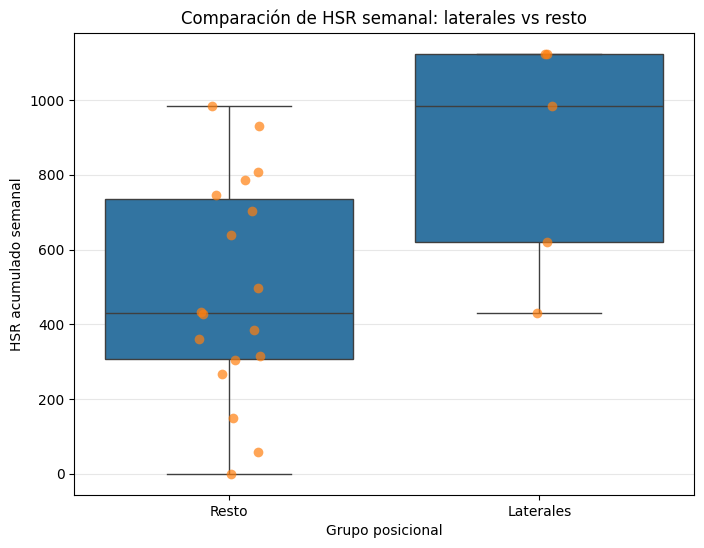

In [44]:
# Boxplot de HSR: laterales vs resto

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="HSR"
)

sns.stripplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="HSR",
    size=7,
    alpha=0.7,
    jitter=True
)

plt.title("Comparación de HSR semanal: laterales vs resto")
plt.xlabel("Grupo posicional")
plt.ylabel("HSR acumulado semanal")
plt.grid(axis="y", alpha=0.3)

plt.show()

El gráfico muestra que los laterales presentaron mayor HSR acumulado semanal que el resto de posiciones. Esta diferencia fue estadísticamente significativa según Mann-Whitney U (p = 0.0187), lo que apoya la hipótesis de una mayor exigencia específica del puesto durante la semana.

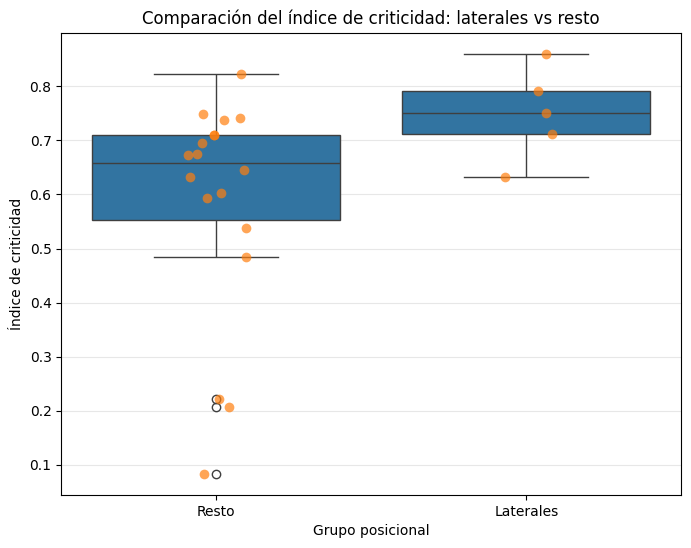

In [45]:
# Boxplot de índice de criticidad: laterales vs resto

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="Indice_criticidad"
)

sns.stripplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="Indice_criticidad",
    size=7,
    alpha=0.7,
    jitter=True
)

plt.title("Comparación del índice de criticidad: laterales vs resto")
plt.xlabel("Grupo posicional")
plt.ylabel("Índice de criticidad")
plt.grid(axis="y", alpha=0.3)

plt.show()

El índice de criticidad también fue significativamente mayor en laterales que en el resto de posiciones (p = 0.0187). Esto sugiere que la mayor exigencia no se limita a una variable aislada, sino que combina carga externa, alta intensidad, RPE y wellness.

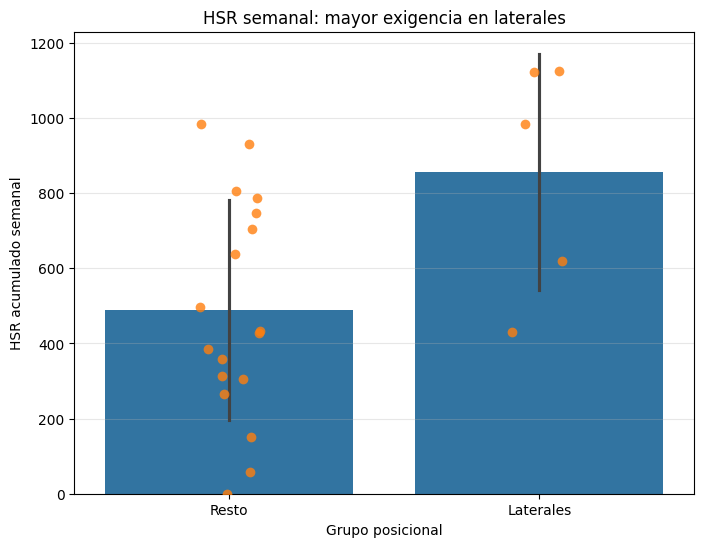

In [46]:
# Gráfico ejecutivo: medias de HSR con jugadores individuales

plt.figure(figsize=(8, 6))

sns.barplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="HSR",
    errorbar="sd"
)

sns.stripplot(
    data=resumen_jugadores_grafico,
    x="Grupo_posicional",
    y="HSR",
    size=7,
    alpha=0.8,
    jitter=True
)

plt.title("HSR semanal: mayor exigencia en laterales")
plt.xlabel("Grupo posicional")
plt.ylabel("HSR acumulado semanal")
plt.grid(axis="y", alpha=0.3)

plt.show()

La hipótesis planteaba que el cambio de sistema hacia 5-3-2 pudo aumentar la exigencia física de los laterales, acercándolos al rol de carrileros.

Los resultados apoyan parcialmente esta hipótesis: los laterales no mostraron diferencias significativas en distancia total ni Player Load, pero sí presentaron mayor HSR e índice de criticidad que el resto de posiciones.

Esto sugiere que la mayor demanda semanal se expresó principalmente en esfuerzos de alta intensidad y no solo en volumen total.